In [242]:
import pandas as pd
import json
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import seaborn as sns

In [243]:
# Tiến hành định nghĩa engine để kết nối dữ liệu và hiển thị
engine = create_engine("sqlite:///../data/sample_strategy/sample_v3.db")

In [244]:
df = pd.read_sql(
    'select x1, x2, x3, x4, x5, x6, x7, x8, x9, y from NearsestSample',
    engine
)

In [245]:
tables = ['air_pollution', 'alcohol_consumption', 'BMI', 'cholesterol', 'diabetes', 'glucose', 'infrastructure', 'physical_activities', 'tobacco', 'cardiovascular_diseases']
df.columns = tables

In [246]:
df.describe()

,air_pollution,alcohol_consumption,BMI,cholesterol,diabetes,glucose,infrastructure,physical_activities,tobacco,cardiovascular_diseases
count,2.688000e+04,41770.000000,42240.000000,40320.000000,42240.000000,32160.000000,3673.000000,42240.000000,42240.000000,42240.000000
mean,6.317306e+03,45.956512,23.085186,3.045846,27.646700,7.433993,0.576967,25.861682,24.518246,20.935218
std,2.116032e+05,67.708479,18.272723,1.452707,53.749641,2.989255,0.850939,11.820362,15.626390,8.468665
min,0.000000e+00,0.000000,0.182635,0.700000,0.800000,1.600000,0.000000,2.543773,0.000000,4.300000
25%,5.285850e+01,21.464858,7.789447,1.300000,6.100000,5.400000,0.120000,17.346439,12.400000,14.400000
50%,1.937835e+02,38.710119,21.433713,3.400000,13.732732,7.200000,0.280000,23.572474,23.400000,20.100000
75%,5.922138e+02,55.804443,28.300000,4.200000,40.963509,8.800000,0.710000,32.378054,33.900000,26.100000
max,2.509519e+07,2219.000000,93.774068,5.600000,1571.000000,25.100000,5.910000,72.908913,82.200000,52.600000


In [247]:
df_dropped = df.drop(columns=["infrastructure"], inplace=True)
df_dropped = df.dropna()
df_dropped.describe()

,air_pollution,alcohol_consumption,BMI,cholesterol,diabetes,glucose,physical_activities,tobacco,cardiovascular_diseases
count,1.659600e+04,16596.000000,16596.000000,16596.000000,16596.000000,16596.000000,16596.000000,16596.000000,16596.000000
mean,5.599712e+03,49.194072,23.235068,3.033966,19.980562,8.049168,25.716283,23.445565,20.467028
std,2.596430e+05,63.522922,17.811167,1.438245,18.703821,3.236594,11.643210,14.848710,8.326985
min,0.000000e+00,2.499687,0.236052,0.700000,2.800000,2.000000,3.585325,0.000000,5.000000
25%,5.526900e+01,24.887886,8.368501,1.300000,5.900000,5.700000,17.405838,12.100000,13.900000
50%,1.949520e+02,40.303123,22.500000,3.400000,10.100000,7.800000,23.506855,22.700000,19.400000
75%,5.754022e+02,57.188808,27.600000,4.200000,31.303502,9.500000,32.085087,32.300000,25.600000
max,2.509519e+07,1277.000000,92.470789,5.400000,83.631510,25.100000,69.205147,78.200000,50.300000


In [248]:
# Tiến hành vẽ biểu đồ tương quan
corr = df_dropped.corr()

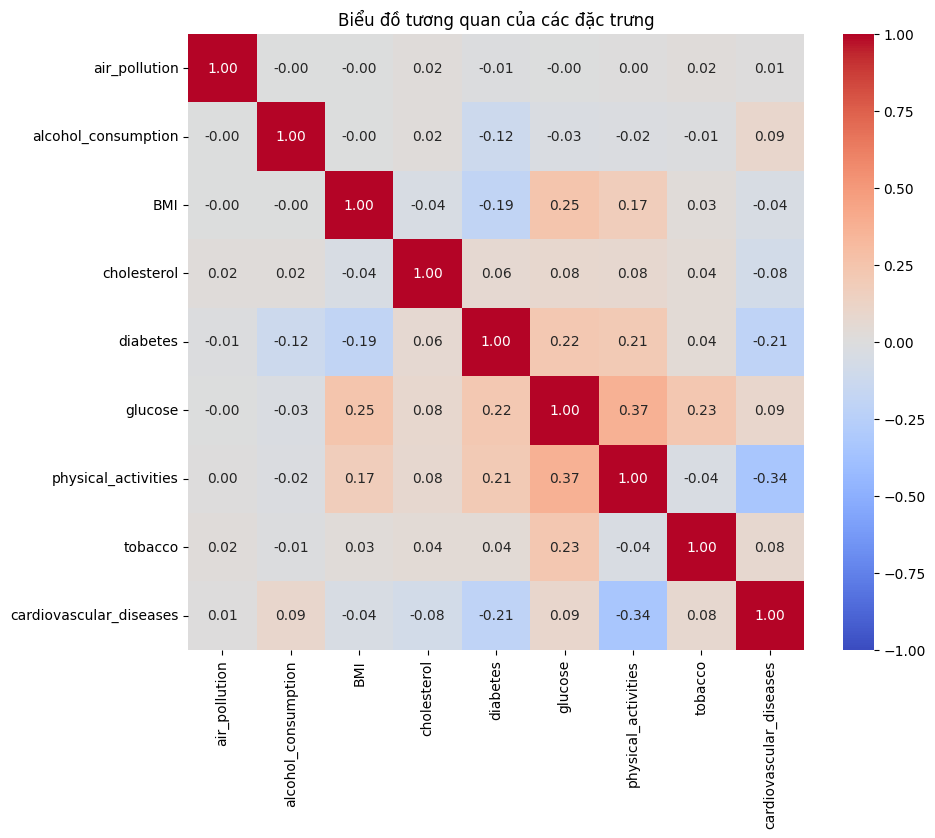

In [249]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,        # hiện giá trị corr
    fmt=".2f",
    cmap="coolwarm",   # thang màu phổ biến cho corr
    vmin=-1, vmax=1,
    square=True
)
plt.title("Biểu đồ tương quan của các đặc trưng")
plt.show()